In [ ]:
!pip uninstall -y tensorflow-datasets protobuf
!pip install tensorflow-datasets
import tensorflow as tf
import tensorflow_datasets as tfds
#load the Cats vs dogs dataset only, omly loading the train split as its the only one availabe
#we will manually split into the train data set , validation and tester later
ds_full, ds_info = tfds.load(
    'cats_vs_dogs',
    split='train',
    with_info=True,
    as_supervised=True,
    shuffle_files=True
)
print("Dataset loaded successfully as ds full!")
print(f"Total number of examples in the dataset: {ds_info.splits['train'].num_examples}")

Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10
Found existing installation: protobuf 7.35.1
Uninstalling protobuf-7.35.1:
  Successfully uninstalled protobuf-7.35.1
  Using cached tensorflow_datasets-4.9.10-py3-none-any.whl.metadata (11 kB)
  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
Using cached tensorflow_datasets-4.9.10-py3-none-any.whl (5.3 MB)
Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl (327 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.7GAXK2_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset loaded successfully as ds full!
Total number of examples in the dataset: 23262


In [ ]:
# split ds full in to train , test , validation
train_size = int(0.7 * 23262)
val_size = int(0.15 * 23262)
test_size = int(0.15 * 23262)

ds_train = ds_full.take(train_size)
temp_ds_for_val_test = ds_full.skip(train_size) # Create a separate temporary dataset for val/test splits

ds_val = temp_ds_for_val_test.take(val_size)
ds_test = temp_ds_for_val_test.skip(val_size).take(test_size) # Ensure test_ds takes from remaining after val_ds

print("Split completed successfully")

Split completed successfully


In [ ]:
IMG_SIZE = 150
BATCH_SIZE =16
AUT0TUNE = tf.data.AUTOTUNE

def preprocess_image(image , label):
  image = tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
  image = tf.cast(image, tf.float32)/255.0
  label = tf.cast(label , tf.float32)
  return image ,label

train_ds = ds_train.map(preprocess_image).batch(BATCH_SIZE).prefetch(AUT0TUNE)
val_ds = ds_val.map(preprocess_image).batch(BATCH_SIZE).prefetch(AUT0TUNE)
test_ds = ds_test.map(preprocess_image).batch(BATCH_SIZE).prefetch(AUT0TUNE)

print("Preprocessing completed successfully")

Preprocessing completed successfully


In [ ]:
print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


In [ ]:
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])
model.compile(optimizer = 'adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_ds,epochs=5,validation_data=val_ds)

Epoch 1/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 49s 43ms/step - accuracy: 0.6627 - loss: 0.6001 - val_accuracy: 0.7418 - val_loss: 0.5104
Epoch 2/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.7699 - loss: 0.4782 - val_accuracy: 0.7902 - val_loss: 0.4521
Epoch 3/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.8182 - loss: 0.3974 - val_accuracy: 0.8105 - val_loss: 0.4124
Epoch 4/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.8675 - loss: 0.3048 - val_accuracy: 0.7945 - val_loss: 0.4898
Epoch 5/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9160 - loss: 0.2049 - val_accuracy: 0.8097 - val_loss: 0.5539


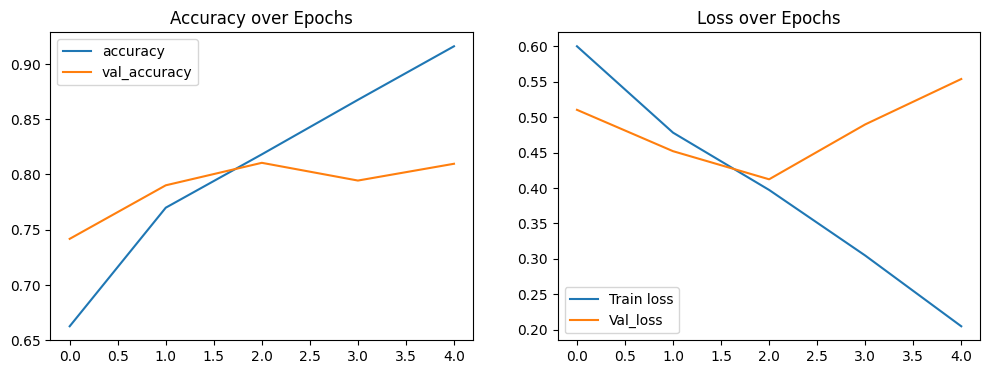

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='Val_loss')
plt.legend()
plt.title("Loss over Epochs")
plt.show()

In [ ]:
# test set pr model evaluate kiya ja rha hai
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.7928 - loss: 0.6001
Test Accuracy: 79.28%


In [ ]:
#Model save cats vs dogs
model.save('cats_vs_dogs_model.h5')

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

Saving 41QZSg8drOL._SY450_.jpg to 41QZSg8drOL._SY450_.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step


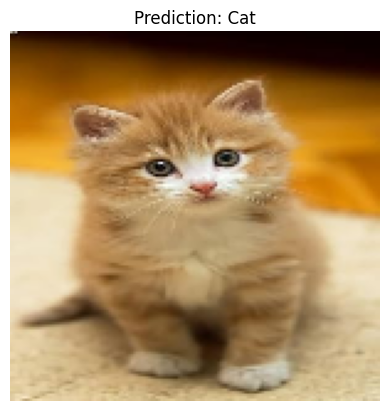

In [ ]:
img = image .load_img(img_path,target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)
img_array /= 255.0
prediction = model.predict(img_array)
label = "Dog" if prediction [0] >0.5 else "Cat"
plt.imshow(img)
plt.title(f"Prediction: {label}")
plt.axis("off")
plt.show()